In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import HTML
import random

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score
import torch
from transformers import AutoTokenizer, AutoModel
import fasttext.util
import pickle
from sklearn.preprocessing import label_binarize

# Настройки
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

RANDOM_STATE = 42
random.seed(42)
np.random.seed(42)

## Данные

### Загрузка данных

In [ ]:
# Импортируем данные
file_id = '1H3hByerVsbJd-mR7I8LK60RpL_87sNza'
url = f'https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t'
data = pd.read_csv(url)
data.head()

,label,comment,cleaned_comment,comment_without_punct,length_sym,length_words,av_word_len,is_normal,swearing,has_positive_emoji,has_negative_emoji,has_obscene_emoji,imperative,2nd_prsn_count,3nd_prsn_count,adj_count,vocative,expr_punct
0,INSULT,скотина! что сказать,скотина сказать,скотина что сказать,20,3,5.67,False,False,False,False,False,False,0,0,0,True,False
1,NORMAL,я сегодня проезжала по рабочей и между домами ...,сегодня проезжать рабочий дом снитенко гомолыс...,я сегодня проезжала по рабочей и между домами ...,180,28,5.21,True,False,False,False,False,False,0,0,3,False,False
2,NORMAL,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,очередной лохотрон зачем придумывать очередной...,379,54,5.78,True,False,False,False,False,False,0,0,8,False,True
3,NORMAL,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,ретро дежавю сложно понять чужое сердце лиш ощ...,72,10,5.70,True,False,False,False,False,False,0,0,0,False,True
4,NORMAL,а когда мы статус агрогородка получили?,статус агрогородок получить,а когда мы статус агрогородка получили,39,6,5.50,True,False,False,False,False,False,0,0,0,False,False


В дальнейшем построении моделей мне не понадобятся большинство столбцов, поэтому удалим все лишнее

**Оставляем столбцы:**

- `label`: класс токсичности (NORMAL, INSULT, THREAT, OBSCENITY)
- `comment`: изначальный комментарий
- `comment_without_punct`: комментарий без знаков пунктуации, чисел, эмодзи
- `cleaned_comment`: *comment_without_punct* комментарий, в котором также удалены стоп-слова, а остальные слова приведены к начальной форме (лемматизированы).

In [7]:
df = data.copy()
df = df[['label', 'comment', 'cleaned_comment', 'comment_without_punct']]

### Пропуски

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248281 entries, 0 to 248280
Data columns (total 4 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   label                  248281 non-null  object
 1   comment                248281 non-null  object
 2   cleaned_comment        246936 non-null  object
 3   comment_without_punct  248281 non-null  object
dtypes: object(4)
memory usage: 7.6+ MB


В столбце `cleaned_comment` есть пропуски. Проверим, почему так получилось

In [9]:
df[df['cleaned_comment'].isnull()]

,label,comment,cleaned_comment,comment_without_punct
238,NORMAL,ч о я,NaN,ч о я
848,NORMAL,|) так и есть.,NaN,так и есть
862,NORMAL,80 тоже такие,NaN,тоже такие
1057,NORMAL,ну может 3-5,NaN,ну может -
1245,NORMAL,"есть такие,есть...",NaN,есть такие есть
...,...,...,...,...
247356,NORMAL,это кто такие?,NaN,это кто такие
247449,NORMAL,его бы так,NaN,его бы так
247470,NORMAL,все 👍👍👍♥♥♥,NaN,все
247677,NORMAL,1 и только 1,NaN,и только


Видно, что это комментарии, которые не несут содержательного смысла. Все что в них есть -- это пунктуация и стоп-слова

Так как пропусков по столбцу `comment_without_punct` нет, то заменим пустые значения в столбце `cleaned_comment` на `comment_without_punct`, чтобы было на чем обучать модель

In [10]:
df['cleaned_comment'] = np.where(df['cleaned_comment'].isna(), df['comment_without_punct'], df['cleaned_comment'])

In [11]:
# Разобьем данные на X и y
X = df['cleaned_comment'].astype(str).tolist()
y = df['label']

## Модель fasttext + LogisticRegression

Что делает fasttext:
1) Разбивает комментарий на слова
2) Разбивает слова на n-граммы и находит вектор, соответствующей каждой n-грамме
3) Суммирует все n-граммы, чтобы получить эмбеддинг слова
4) Усредняет эмбеддинги всех слов в предложении, чтобы получить финальный эмбеддинг для комментария

Преимущество fasttext по сравнению с более простыми техниками векторизации в том, что он может сопоставить вектор даже неизвестному слову. Но fasttext не учитывает порядок и контекст слов

Далее мы обучаем LogisticRegression на эмбеддингах по каждому комментарию, находя оптимальные веса, и делаем предсказание по этой модели

In [12]:
# Скачиваем модель fasttext
fasttext.util.download_model('ru', if_exists='ignore')
ft = fasttext.load_model('cc.ru.300.bin')

# Проверим размер файла
file_size = os.path.getsize('cc.ru.300.bin') / (1024 ** 3)
print(f'Размер файла: {file_size:.2f} GB')


Размер файла: 6.76 GB


In [13]:
# Посмотрим на примере, как работает модель
# Получение эмбеддинга для слова
word_embedding = ft.get_word_vector('токсичность')
print(f'Как выглядит эмбеддинг слова (первые 10 значений): {word_embedding[:10]}')
print(f'Размер вектора слова: {word_embedding.shape}')

# Получение эмбеддинга для предложения
sentence = 'классификация токсичных комментариев'
words = sentence.split()
sentence_embedding = sum(ft.get_word_vector(word) for word in words) / len(words)
print(f'Размер вектора предложения: {sentence_embedding.shape}', end='\n\n')

# Поиск похожих слов
w = 'магистратура'
neigh = ft.get_nearest_neighbors(w, k=5)
print(f'Наиболее близкие слова к слову "{w}" по мнению fasttext:')
for val, word in neigh:
    print(f'{word}: {val:.3f}')

Как выглядит эмбеддинг слова (первые 10 значений): [-0.06059929  0.00751187  0.01832018  0.05844466  0.03742911  0.04537646
 -0.01716838  0.0611634  -0.01818082 -0.04319054]
Размер вектора слова: (300,)
Размер вектора предложения: (300,)

Наиболее близкие слова к слову "магистратура" по мнению fasttext:
аспирантура: 0.701
бакалавриат: 0.688
магистратуры: 0.679
Магистратура: 0.666
магистратуру: 0.659


In [14]:
# Разделим выборку на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

Создадим функцию `fasttext_embeddings`, которая будет находить эмбеддинг для каждого комментария с помощью Fasttext, чтобы потом на этих векторах обучать LogisticRegression

Так как у нас большая выборка, будем обрабатывать комментарии по блокам (батчам), чтобы не перегружать RAM, а также добавим шкалу обработки для наглядности

In [15]:
def fasttext_embeddings(comments):
    embeddings = []
    for comment in comments:
        words = comment.split()
        # Ранее проверяла, что в столбце нет пустых значений, но для чистоты кода добавим проверку на пропуски
        if not words:
            embeddings.append(np.zeros(300))
            continue
            
        vectors = [ft.get_word_vector(word) for word in words if word in ft.words]
        
        if vectors:
            embeddings.append(np.mean(vectors, axis=0))
        else:
            embeddings.append(np.zeros(300))
    return embeddings

def process_embedding(comments, batch_size, desc):
    result = []
    for i in tqdm(range(0, len(comments), batch_size), desc=desc):
        batch_comments = comments[i:i + batch_size]
        batch_embeddings = fasttext_embeddings(batch_comments)
        result.extend(batch_embeddings)
    
    return np.array(result)

In [16]:
# Найдем эмбеддинги
X_vectors_train = process_embedding(X_train, batch_size=500, desc='Векторизация train')
X_vectors_test = process_embedding(X_test, batch_size=1000, desc='Векторизация test')

Векторизация train:   0%|          | 0/398 [00:00<?, ?it/s]

Векторизация test:   0%|          | 0/50 [00:00<?, ?it/s]

In [17]:
# Обучим модель LogisticRegression без регуляризации
model_fasttext = LogisticRegression(max_iter=1000, penalty=None, solver='lbfgs')
model_fasttext.fit(X_vectors_train, y_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
# Предсказываем класс на тестовых и трейновых данных
pred_fasttext = model_fasttext.predict(X_vectors_test)
pred_fasttext_proba = model_fasttext.predict_proba(X_vectors_test)
pred_fasttext_train = model_fasttext.predict(X_vectors_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, pred_fasttext_train, average="macro"):.4f}')

F1 (macro) на train выборке: 0.7039


In [19]:
# Проверим метрики качества
def quality_metrics(y_true, y_pred, model_name):

    print(f'Метрики качества {model_name}')
    print('-' * 40)
    
    display(HTML(f'<b>F1 (macro):  {f1_score(y_true, y_pred, average="macro"):.4f}</b>'))
    print(f'Accuracy:    {(y_pred == y_true).mean():.0%}')
    print(f'Precision:   {precision_score(y_true, y_pred, average="macro"):.3f}')
    print(f'Recall:      {recall_score(y_true, y_pred, average="macro"):.3f}')

    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred))


quality_metrics(y_test, pred_fasttext, 'FastText + LogisticRegression')

Метрики качества FastText + LogisticRegression
----------------------------------------


Accuracy:    90%
Precision:   0.786
Recall:      0.641

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.74      0.58      0.65      5713
      NORMAL       0.93      0.98      0.95     40736
   OBSCENITY       0.74      0.50      0.59       852
      THREAT       0.74      0.51      0.61      2356

    accuracy                           0.90     49657
   macro avg       0.79      0.64      0.70     49657
weighted avg       0.89      0.90      0.90     49657



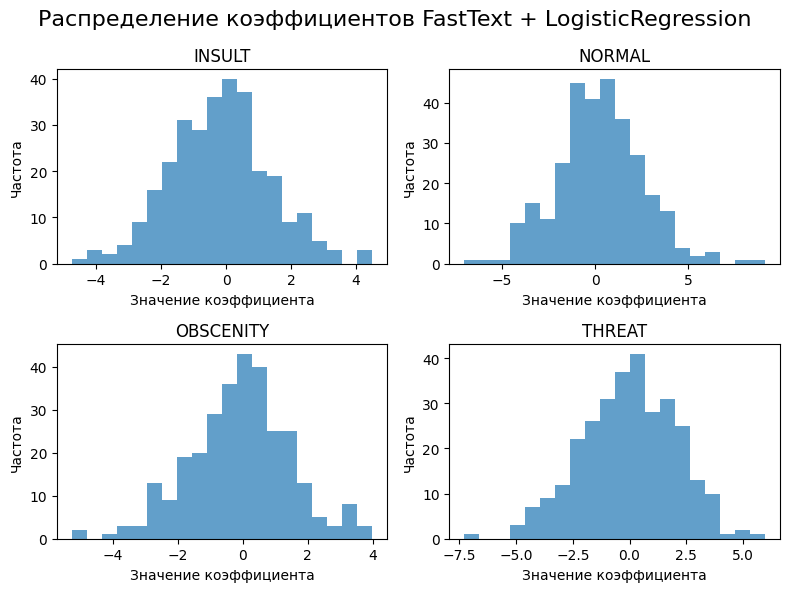

In [20]:
# Посмотрим, как выглядят веса модели
def coef_graphs(model, model_name=None):
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    fig.suptitle(f'Распределение коэффициентов {model_name}', fontsize=16)

    titles = model.classes_

    for idx, ax in enumerate(axes.flat):
        if idx < len(model.coef_):
            ax.hist(model.coef_[idx], bins=20, alpha=0.7)
            ax.set_title(titles[idx])
            ax.set_xlabel('Значение коэффициента')
            ax.set_ylabel('Частота')

    plt.tight_layout()
    plt.show()

coef_graphs(model_fasttext, model_name='FastText + LogisticRegression')

### Lasso регуляризация

F1 для train и test очень похожие, а веса сосредоточены вокруг 0, поэтому можно предположить, что у нас нет переобучения, но давайте все же посмотрим, сможет ли регуляризация дать прирост в метриках качества

In [21]:
# Не получилось подобрать оптимальный гиперпараметр Lasso с помощью GridSearchCV (бесконечно прогружалось)
# Поэтому разобьем train на новый train и валидацию и переберем несколько гиперпараметров вручную
X_vectors_train_l1, X_vectors_val_l1, y_train_l1, y_val_l1 = train_test_split(X_vectors_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)
best_f1_l1 = 0

for C in [0.001, 0.01, 0.1, 1, 10, 15]:
    model = LogisticRegression(penalty='l1', C=C, solver='saga', max_iter=1000, random_state=42)
    model.fit(X_vectors_train_l1, y_train_l1)
    
    f1_fasttext_l1 = f1_score(y_val_l1, model.predict(X_vectors_val_l1), average='macro')
    print(f'C={C}: F1 = {f1_fasttext_l1:.4f}')
    
    if f1_fasttext_l1 > best_f1_l1:
        best_f1_l1 = f1_fasttext_l1
        best_model_fasttext_l1 = model

print(f'Лучшая модель: C={best_model_fasttext_l1.C}, F1={best_f1_l1:.4f}')

C=0.001: F1 = 0.2264
C=0.01: F1 = 0.3506
C=0.1: F1 = 0.6252
C=1: F1 = 0.6911
C=10: F1 = 0.6958
C=15: F1 = 0.6965
Лучшая модель: C=15, F1=0.6965


In [22]:
# Предсказываем класс на тестовых и трейновых данных
pred_fasttext_l1 = best_model_fasttext_l1.predict(X_vectors_test)
pred_fasttext_train_l1 = best_model_fasttext_l1.predict(X_vectors_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, pred_fasttext_train_l1, average="macro"):.4f}')
quality_metrics(y_test, pred_fasttext_l1, 'FastText + LogisticRegression + L1 Reg')

F1 (macro) на train выборке: 0.7055
Метрики качества FastText + LogisticRegression + L1 Reg
----------------------------------------


Accuracy:    90%
Precision:   0.784
Recall:      0.642

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.74      0.57      0.65      5713
      NORMAL       0.93      0.98      0.95     40736
   OBSCENITY       0.73      0.50      0.59       852
      THREAT       0.74      0.51      0.61      2356

    accuracy                           0.90     49657
   macro avg       0.78      0.64      0.70     49657
weighted avg       0.89      0.90      0.90     49657



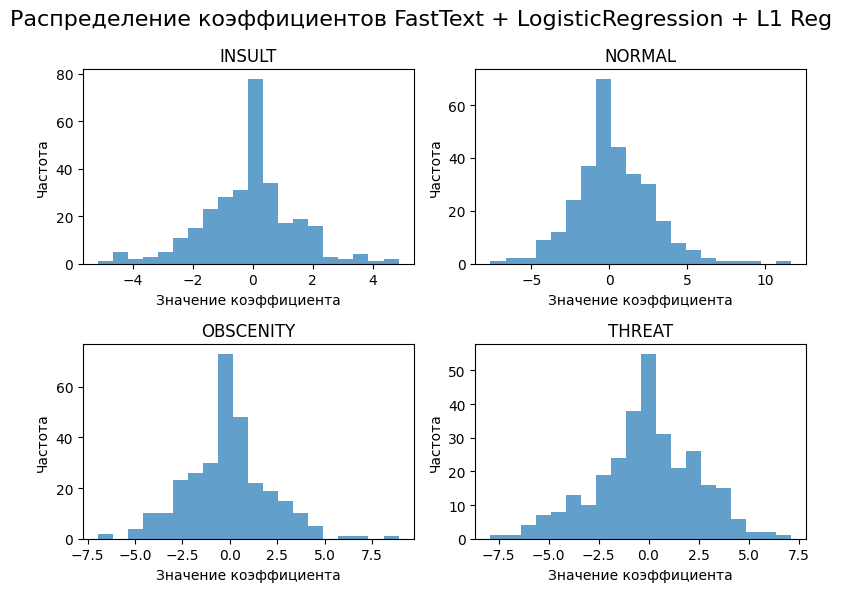

In [23]:
# Посмотрим на распределение коэффициентов
coef_graphs(best_model_fasttext_l1, model_name='FastText + LogisticRegression + L1 Reg')

In [24]:
# У Lasso регуляризации есть тенденция к частому занулению весов. 
# Проверим, занулила ли она какие-то коэффициенты в этом случае
null_coefs = 0
for i in range(0, 4):
    for coef in best_model_fasttext_l1.coef_[i]:
        if coef == 0:
            null_coefs += 1
print(f'L1 регуляризация занулила {null_coefs} весов')

L1 регуляризация занулила 48 весов


### Ridge регуляризация

In [25]:
# C помощью GridSearchCV подберем оптимальный гиперпараметр для модели с l2 регуляризацией
params = {'C': [0.1, 0.5, 1, 5, 10], 'penalty':  ['l2'], 'solver': ['lbfgs'], 'max_iter': [1000]}

model_fasttext_l2 = GridSearchCV(LogisticRegression(max_iter=1000), params, scoring='f1_macro', cv=3, n_jobs=-1, verbose=1)
model_fasttext_l2.fit(X_vectors_train, y_train)

print(f'Лучшие параметры: {model_fasttext_l2.best_params_}')
print(f'Лучший f1 score: {model_fasttext_l2.best_score_:.4f}')

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Лучшие параметры: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Лучший f1 score: 0.6974


In [26]:
# Предсказываем класс на тестовых и трейновых данных
pred_fasttext_l2 = model_fasttext_l2.predict(X_vectors_test)
pred_fasttext_train_l2 = model_fasttext_l2.predict(X_vectors_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, pred_fasttext_train_l2, average="macro"):.4f}')
quality_metrics(y_test, pred_fasttext_l2, 'FastText + LogisticRegression + L2 Reg')

F1 (macro) на train выборке: 0.7026
Метрики качества FastText + LogisticRegression + L2 Reg
----------------------------------------


Accuracy:    90%
Precision:   0.788
Recall:      0.639

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.74      0.57      0.65      5713
      NORMAL       0.93      0.98      0.95     40736
   OBSCENITY       0.74      0.49      0.59       852
      THREAT       0.75      0.51      0.61      2356

    accuracy                           0.90     49657
   macro avg       0.79      0.64      0.70     49657
weighted avg       0.89      0.90      0.89     49657



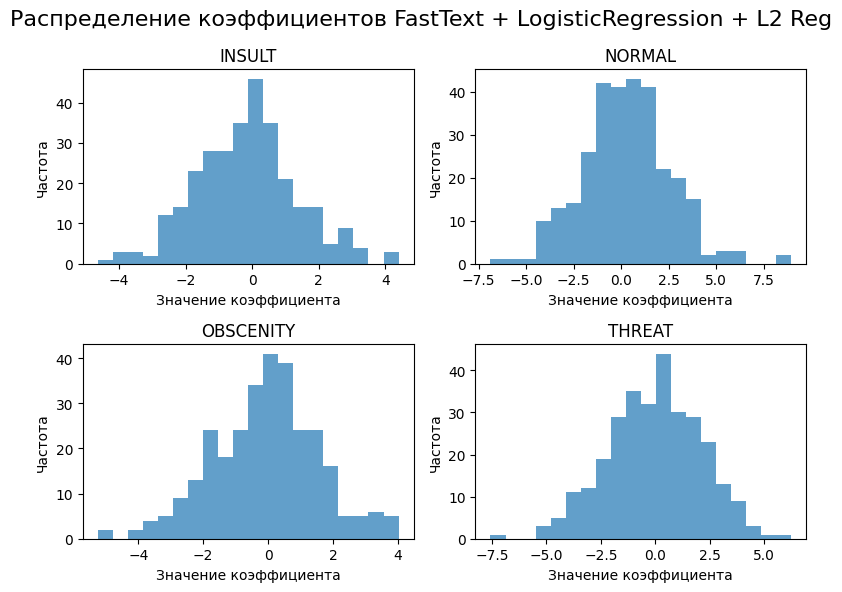

In [27]:
# Посмотрим на распределение коэффициентов
coef_graphs(model_fasttext_l2.best_estimator_, model_name='FastText + LogisticRegression + L2 Reg')

In [28]:
# Проверим, занулила ли Ridge регуляризация какие-то коэффициенты (хотя вероятность этого мала)
null_coefs = 0
for i in range(0, 4):
    for coef in model_fasttext_l2.best_estimator_.coef_[i]:
        if abs(coef) == 0:
            null_coefs += 1
print(f'L2 регуляризация занулила {null_coefs} весов')

L2 регуляризация занулила 0 весов


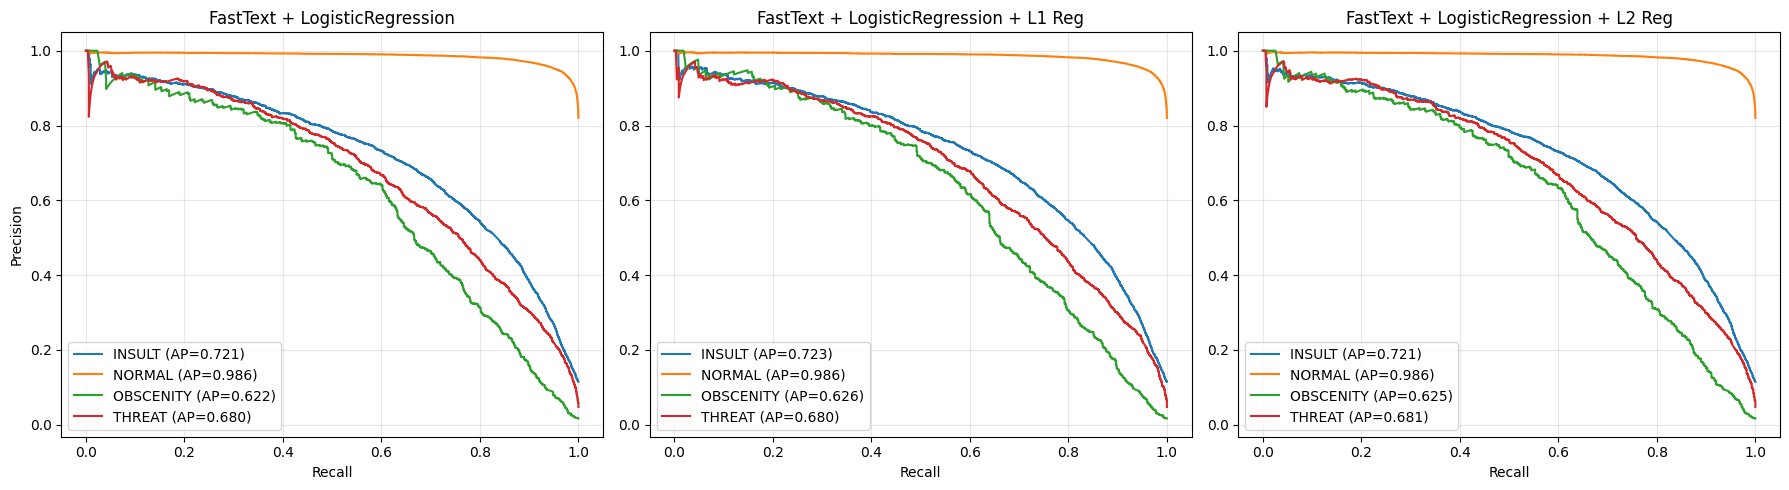

In [29]:
# Визуализируем PR кривые для отражения того, какие классы лучше предсказываются моделями
def plot_pr(models, names, X, y):
    
    classes = np.sort(np.unique(y))
    y_bin = label_binarize(y, classes=classes)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for model, name, ax in zip(models, names, axes):
        probs = model.predict_proba(X)
        
        for i, cls in enumerate(classes):
            prec, rec, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
            ap = average_precision_score(y_bin[:, i], probs[:, i])
            ax.plot(rec, prec, label=f'{cls} (AP={ap:.3f})')
        
        ax.set_xlabel('Recall')
        if ax == axes[0]:
            ax.set_ylabel('Precision')
        ax.set_title(name)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_pr(models=[model_fasttext, best_model_fasttext_l1, model_fasttext_l2],
        names=['FastText + LogisticRegression', 'FastText + LogisticRegression + L1 Reg', 'FastText + LogisticRegression + L2 Reg'],
        X=X_vectors_test,
        y=y_test)

### Выводы:
Было построено 3 модели с FastText + LogisticRegression:
- без регуляризации (F1 = 0.6997)
- с L1-регуляризацией (F1 = 0.7)
- с L2-регуляризацией (F1 = 0.699)

То есть можно сказать, что по нашей ключевой метрике качества разницы в моделях нет. Нужно отметить, что другие метрики качества также не сильно различаются между моделями, но, например, F1 weighted показывает гораздо более высокое качество (~0.9), чем F1 macro, так как учитывает, что наиболее часто встречающийся класс мы предсказываем правильно чаще, чем малочисленные классы

При этом в каждой модели коэффициенты сосредоточены вокруг 0 и, как видно на PR-кривой, каждая лучше всего предсказывает класс NORMAL и хуже всего OBSCENITY

Но у Lasso модели есть особенность в виде того, что она зануляет часть весов (в этом случае 48 весов), что немного облегчает дальнейшее использование. Поэтому будем считать, что оптимальная модель FastText + LogisticRegression -- это модель с L1-регуляризацией

## BERT + LogisticRegression

Используем предобученный BERT для получения эмбеддингов комментариев. Токенизатор разбивает комментарий на токены, а модель BERT вычисляет эмбеддинги для каждого токена в комментарии. Для получения итогового вектора для каждого комментария мы применяем операцию Mean Pooling (усредняем по всем токенам). Далее на этих векторах обучаем LogisticRegression и находим оптимальные веса

In [30]:
# Берем маленькую русскую BERT модель
tokenizer_bert = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
bert = AutoModel.from_pretrained("cointegrated/rubert-tiny2")

In [ ]:
# Используем BERT как векторайзер
bert.eval()

def bert_vectors(comments, batch_size=16, max_length=256, desc='Векторизация'):
    device = torch.device('mps')
    bert.to(device)
    result = []

    # Обрабатываем комментарии по батчам для экономии памяти
    for i in tqdm(range(0, len(comments), batch_size), desc=desc):
        batch_comments = comments[i:i + batch_size]
        # Токенизируем комментарии
        inputs = tokenizer_bert(batch_comments, return_tensors='pt', truncation=True, padding=True, max_length=max_length).to(device)

        # Находим эмбеддинги комментариев
        with torch.no_grad():
            outputs = bert(**inputs)

        # Усредненяем вектора по его токенам
        batch_vectors = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        result.append(batch_vectors)

    return np.vstack(result)

In [32]:
X_bert_train = bert_vectors(X_train, batch_size=16, desc='Векторизация train')
X_bert_test = bert_vectors(X_test, batch_size=16, desc='Векторизация test')

Векторизация train:   0%|          | 0/12414 [00:00<?, ?it/s]

Векторизация test:   0%|          | 0/3104 [00:00<?, ?it/s]

In [33]:
# Обучим модель
model_bert = LogisticRegression(max_iter=1000, penalty=None, solver='lbfgs')
model_bert.fit(X_bert_train, y_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
# Предсказываем класс на тестовых и трейновых данных
pred_bert = model_bert.predict(X_bert_test)
#pred_bert_proba = model_bert.predict_proba(X_bert_test)
pred_bert_train = model_bert.predict(X_bert_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, pred_bert_train, average="macro"):.4f}')

F1 (macro) на train выборке: 0.6549


In [35]:
# Проверим метрики качества
quality_metrics(y_test, pred_bert, 'BERT + LogisticRegression')

Метрики качества BERT + LogisticRegression
----------------------------------------


Accuracy:    89%
Precision:   0.733
Recall:      0.599

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.70      0.57      0.63      5713
      NORMAL       0.93      0.97      0.95     40736
   OBSCENITY       0.65      0.36      0.46       852
      THREAT       0.65      0.49      0.56      2356

    accuracy                           0.89     49657
   macro avg       0.73      0.60      0.65     49657
weighted avg       0.88      0.89      0.89     49657



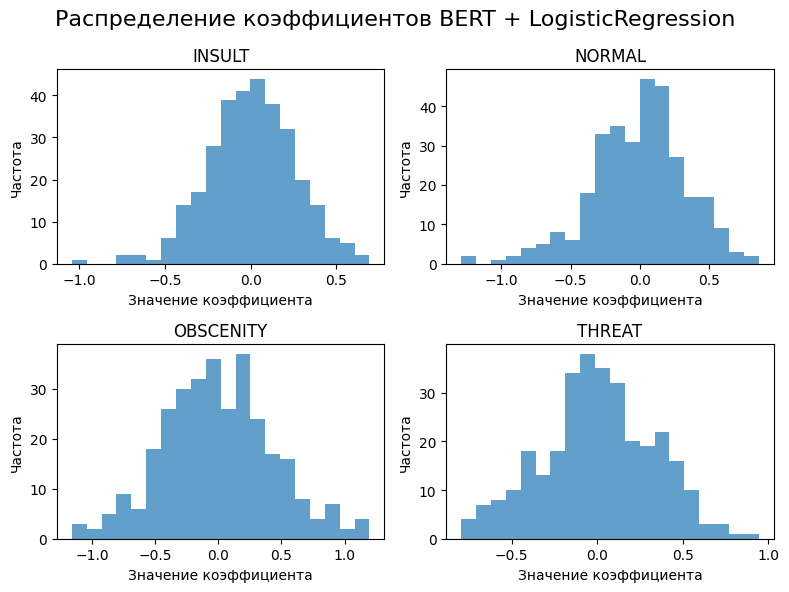

In [36]:
# Посмотрим на распределение коэффициентов
coef_graphs(model_bert, model_name='BERT + LogisticRegression')

### Lasso регуляризация

In [37]:
# C помощью GridSearchCV подберем оптимальный гиперпараметр для модели с l1 регуляризацией
params = {'C': [0.1, 0.5, 1, 5, 10, 15], 'penalty':  ['l1'], 'solver': ['saga'], 'max_iter': [1000]}

model_bert_l1 = GridSearchCV(LogisticRegression(max_iter=1000), params, scoring='f1_macro', cv=3, n_jobs=-1, verbose=1)
model_bert_l1.fit(X_bert_train, y_train)

print(f'Лучшие параметры: {model_bert_l1.best_params_}')
print(f'Лучший f1 score: {model_bert_l1.best_score_:.4f}')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Лучшие параметры: {'C': 15, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Лучший f1 score: 0.6484


In [38]:
# Предсказываем класс на тестовых и трейновых данных
pred_bert_l1 = model_bert_l1.predict(X_bert_test)
#pred_bert_proba = model_bert.predict_proba(X_bert_test)
pred_bert_train_l1 = model_bert_l1.predict(X_bert_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, pred_bert_train_l1, average="macro"):.4f}')

F1 (macro) на train выборке: 0.6544


In [39]:
# Проверим метрики качества
quality_metrics(y_test, pred_bert_l1, 'BERT + LogisticRegression + L1 Reg')

Метрики качества BERT + LogisticRegression + L1 Reg
----------------------------------------


Accuracy:    89%
Precision:   0.730
Recall:      0.597

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.70      0.57      0.63      5713
      NORMAL       0.93      0.97      0.95     40736
   OBSCENITY       0.64      0.35      0.46       852
      THREAT       0.65      0.49      0.56      2356

    accuracy                           0.89     49657
   macro avg       0.73      0.60      0.65     49657
weighted avg       0.88      0.89      0.89     49657



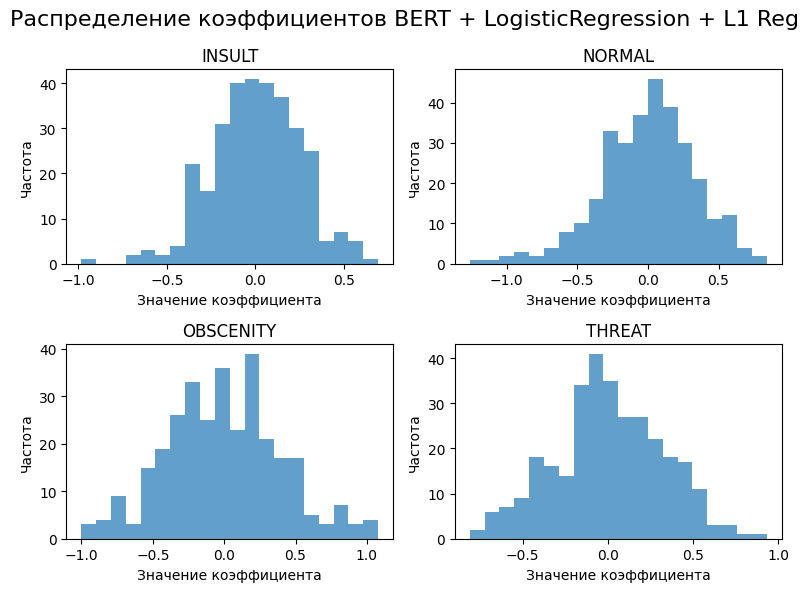

In [40]:
# Посмотрим на распределение коэффициентов
coef_graphs(model_bert_l1.best_estimator_, model_name='BERT + LogisticRegression + L1 Reg')

In [47]:
# У Lasso регуляризации есть тенденция к частому занулению весов. 
# Проверим, занулила ли она какие-то коэффициенты в этом случае
null_coefs = 0
for i in range(0, 4):
    for coef in model_bert_l1.best_estimator_.coef_[i]:
        if coef == 0:
            null_coefs += 1
print(f'L1 регуляризация занулила {null_coefs} весов')

L1 регуляризация занулила 0 весов


### Ridge регуляризация

In [41]:
# C помощью GridSearchCV подберем оптимальный гиперпараметр для модели с l2 регуляризацией
params = {'C': [0.1, 0.5, 1, 5, 10, 15], 'penalty':  ['l2'], 'solver': ['lbfgs'], 'max_iter': [1000]}

model_bert_l2 = GridSearchCV(LogisticRegression(max_iter=1000), params, scoring='f1_macro', cv=3, n_jobs=-1, verbose=1)
model_bert_l2.fit(X_bert_train, y_train)

print(f'Лучшие параметры: {model_bert_l2.best_params_}')
print(f'Лучший f1 score: {model_bert_l2.best_score_:.4f}')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Лучшие параметры: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Лучший f1 score: 0.6484


In [42]:
# Предсказываем класс на тестовых и трейновых данных
pred_bert_l2 = model_bert_l2.predict(X_bert_test)
#pred_bert_proba = model_bert.predict_proba(X_bert_test)
pred_bert_train_l2 = model_bert_l2.predict(X_bert_train)
print(f'F1 (macro) на train выборке: {f1_score(y_train, pred_bert_train_l2, average="macro"):.4f}')

F1 (macro) на train выборке: 0.6549


In [43]:
# Проверим метрики качества
quality_metrics(y_test, pred_bert_l2, 'BERT + LogisticRegression + L2 Reg')

Метрики качества BERT + LogisticRegression + L2 Reg
----------------------------------------


Accuracy:    89%
Precision:   0.732
Recall:      0.597

Classification Report:
              precision    recall  f1-score   support

      INSULT       0.70      0.57      0.63      5713
      NORMAL       0.93      0.97      0.95     40736
   OBSCENITY       0.64      0.35      0.45       852
      THREAT       0.66      0.49      0.56      2356

    accuracy                           0.89     49657
   macro avg       0.73      0.60      0.65     49657
weighted avg       0.88      0.89      0.89     49657



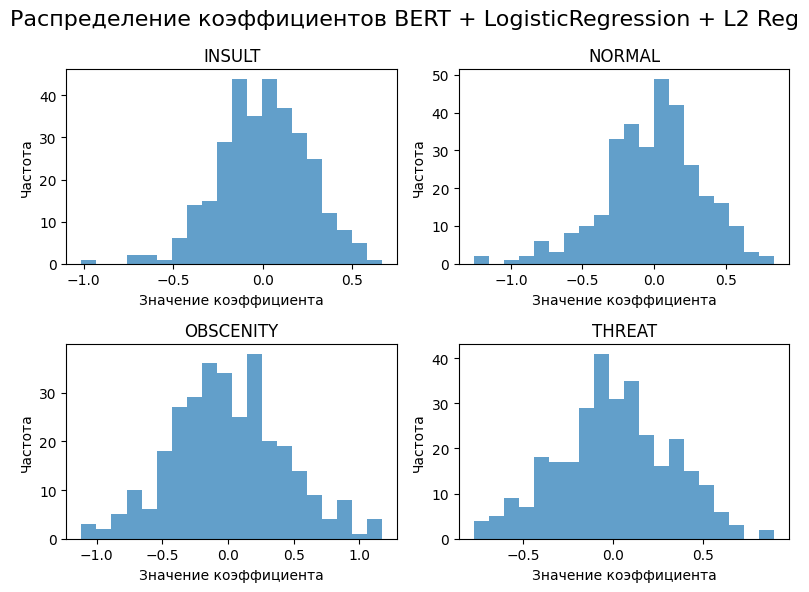

In [44]:
# Посмотрим на распределение коэффициентов
coef_graphs(model_bert_l2.best_estimator_, model_name='BERT + LogisticRegression + L2 Reg')

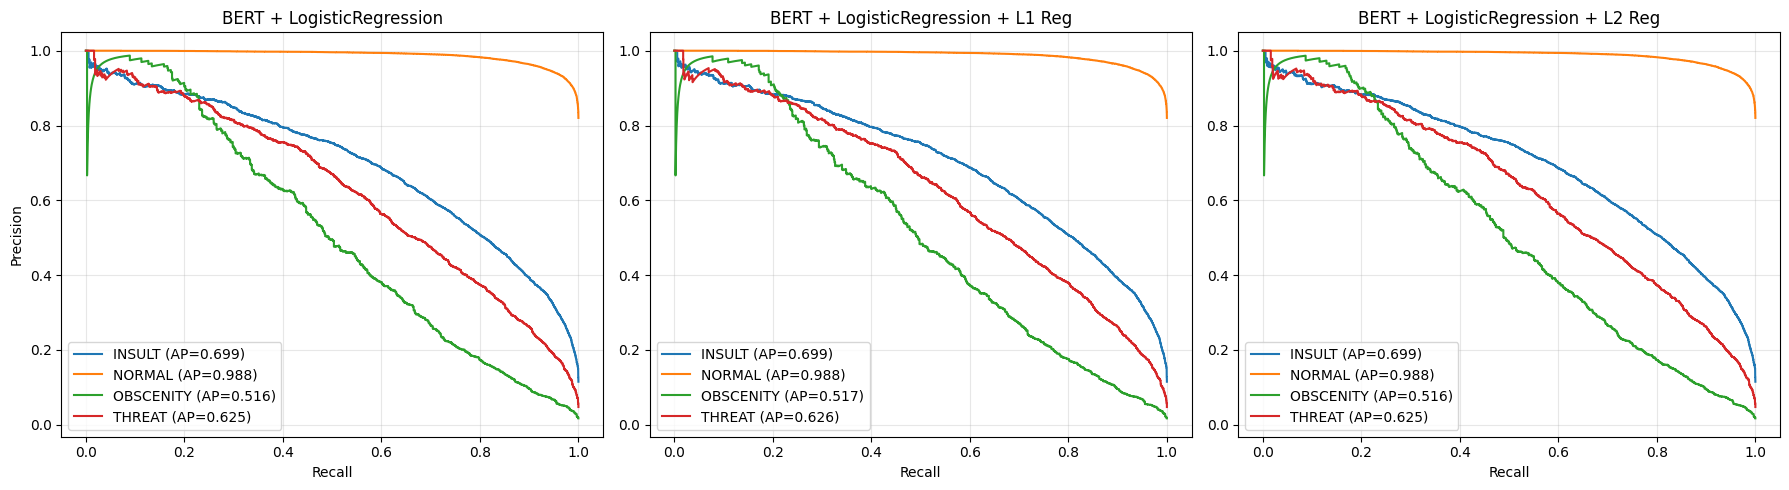

In [45]:
# Визуализируем PR кривые для отражения того, какие классы лучше предсказываются моделями
plot_pr(models=[model_bert, model_bert_l1, model_bert_l2],
        names=['BERT + LogisticRegression', 'BERT + LogisticRegression + L1 Reg', 'BERT + LogisticRegression + L2 Reg'],
        X=X_bert_test,
        y=y_test)

### Выводы:
Было построено 3 модели с BERT + LogisticRegression:
- без регуляризации (F1 = 0.6510)
- с L1-регуляризацией (F1 = 0.6485)
- с L2-регуляризацией (F1 = 0.6489)

Значительной разницы в ключевой метрике качества нет, регуляризация не смогла улучшить изначальную модель

При этом в каждой модели коэффициенты сосредоточены вокруг 0 (хотя даже L1-регуляризация не смогла их занулить) и, как видно на PR-кривой, каждая лучше всего предсказывает класс NORMAL и хуже всего OBSCENITY

Будем считать, что оптимальная модель BERT + LogisticRegression -- это модель без регуляризации, но даже она показывает невысокое качество
